# Parcial Dataset 1 - Ames Housing (Regresion Lineal)

In [10]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

In [11]:
candidate_paths = [
    Path("datasets/ames_housing/AmesHousing.xls"),
    Path("EXAMEN/datasets/ames_housing/AmesHousing.xls"),
    Path.cwd() / "datasets" / "ames_housing" / "AmesHousing.xls",
    Path.cwd() / "EXAMEN" / "datasets" / "ames_housing" / "AmesHousing.xls",
]

dataset_path = None
for p in candidate_paths:
    if p.exists():
        dataset_path = p
        break

if dataset_path is None:
    raise FileNotFoundError("No se encontro AmesHousing.xls en rutas esperadas.")

df = pd.read_excel(dataset_path)
print("Ruta usada:", dataset_path)
print("Shape:", df.shape)
df.head()

Ruta usada: datasets\ames_housing\AmesHousing.xls
Shape: (2930, 82)


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [16]:
target_col = "SalePrice"

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove(target_col)

null_count = df[numeric_cols].isnull().sum().sort_values()
selected_features = list(null_count.index[:10])

work = df[selected_features + [target_col]].dropna().copy()
X = work[selected_features].values
y = work[target_col].values

print("Filas despues de limpieza:", X.shape[0])
print("Features seleccionadas:")
for i, f in enumerate(selected_features, start=1):
    print(f"{i}. {f}")

Filas despues de limpieza: 2930
Features seleccionadas:
1. Order
2. PID
3. MS SubClass
4. Lot Area
5. Overall Cond
6. Overall Qual
7. Year Built
8. Year Remod/Add
9. 1st Flr SF
10. 2nd Flr SF


In [14]:
def split_75_25(X, y, seed=42):
    np.random.seed(seed)
    m = X.shape[0]
    idx = np.random.permutation(m)
    train_size = int(0.75 * m)
    train_idx = idx[:train_size]
    test_idx = idx[train_size:]
    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]


def feature_normalize_train_test(X_train, X_test):
    mu = np.mean(X_train, axis=0)
    sigma = np.std(X_train, axis=0)
    sigma[sigma == 0] = 1.0
    X_train_norm = (X_train - mu) / sigma
    X_test_norm = (X_test - mu) / sigma
    return X_train_norm, X_test_norm, mu, sigma


def add_intercept(X):
    return np.concatenate([np.ones((X.shape[0], 1)), X], axis=1)


def compute_cost(X, y, theta):
    m = y.shape[0]
    return (1 / (2 * m)) * np.sum((X @ theta - y) ** 2)


def gradient_descent(X, y, theta, alpha, num_iters):
    m = y.shape[0]
    J_history = []
    for _ in range(num_iters):
        theta = theta - (alpha / m) * (X.T @ (X @ theta - y))
        J_history.append(compute_cost(X, y, theta))
    return theta, J_history


def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))


def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))


def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)

In [15]:
X_train, X_test, y_train, y_test = split_75_25(X, y, seed=42)
X_train_norm, X_test_norm, mu, sigma = feature_normalize_train_test(X_train, X_test)

X_train_i = add_intercept(X_train_norm)
X_test_i = add_intercept(X_test_norm)

theta = np.zeros(X_train_i.shape[1])
alpha = 0.01
num_iters = 2500

theta, J_history = gradient_descent(X_train_i, y_train, theta, alpha, num_iters)
print("Entrenamiento completado.")
print("Theta (primeros 5):", theta[:5])

Entrenamiento completado.
Theta (primeros 5): [181589.2954006     471.57046255  -1740.92470842  -6380.33149256
   4357.30457017]


In [7]:
y_pred_train = X_train_i @ theta
y_pred_test = X_test_i @ theta

train_rmse = rmse(y_train, y_pred_train)
test_rmse = rmse(y_test, y_pred_test)
train_mae = mae(y_train, y_pred_train)
test_mae = mae(y_test, y_pred_test)
train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)

print("=== RESULTADOS REGRESION ===")
print(f"RMSE train: {train_rmse:.2f}")
print(f"RMSE test : {test_rmse:.2f}")
print(f"MAE train : {train_mae:.2f}")
print(f"MAE test  : {test_mae:.2f}")
print(f"R2 train  : {train_r2:.4f}")
print(f"R2 test   : {test_r2:.4f}")

print("\nControl de sobreajuste:")
if test_rmse <= train_rmse * 1.25:
    print("- Diferencia train/test aceptable. Sobreajuste bajo.")
else:
    print("- Posible sobreajuste. Conviene simplificar features o regularizar.")

=== RESULTADOS REGRESION ===
RMSE train: 36407.83
RMSE test : 35774.34
MAE train : 23686.10
MAE test  : 23733.18
R2 train  : 0.7981
R2 test   : 0.7798

Control de sobreajuste:
- Diferencia train/test aceptable. Sobreajuste bajo.


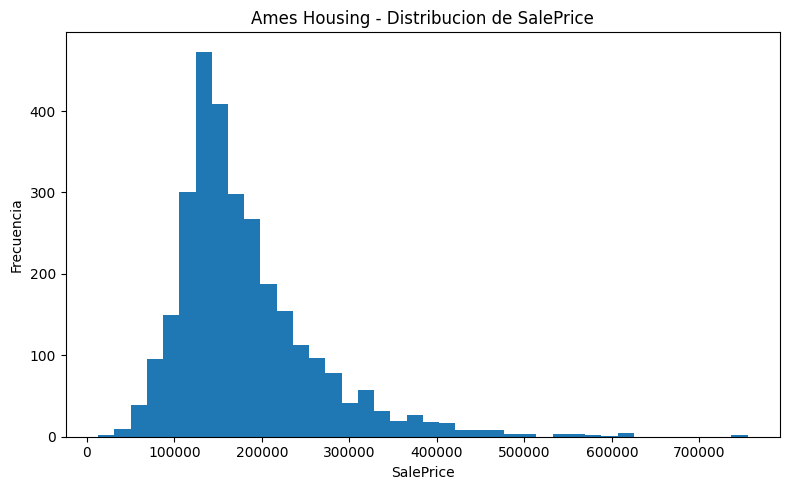

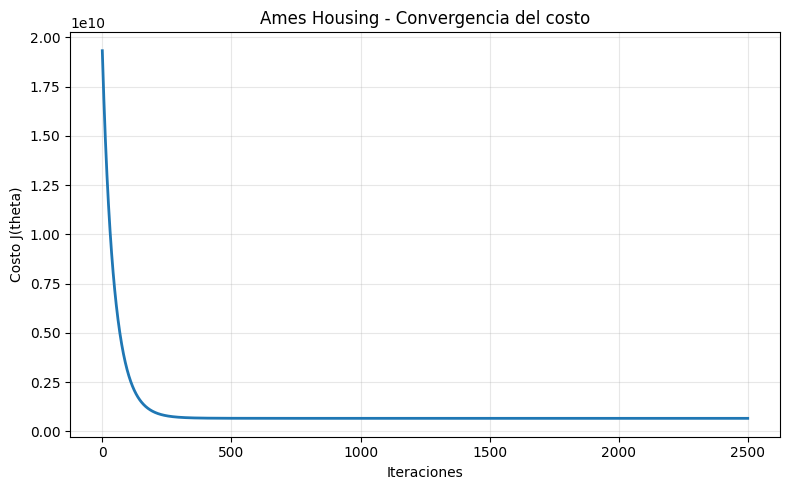

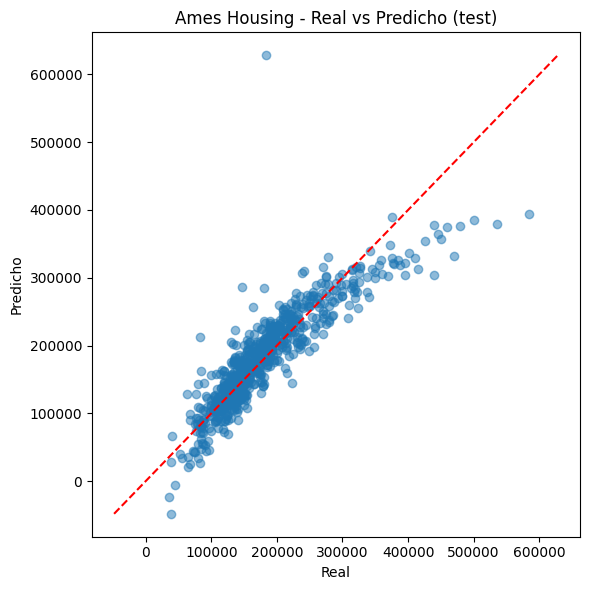

In [17]:
plt.figure(figsize=(8, 5))
plt.hist(y, bins=40)
plt.title("Ames Housing - Distribucion de SalePrice")
plt.xlabel("SalePrice")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(np.arange(len(J_history)), J_history, lw=2)
plt.title("Ames Housing - Convergencia del costo")
plt.xlabel("Iteraciones")
plt.ylabel("Costo J(theta)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_test, alpha=0.5)
min_v = min(np.min(y_test), np.min(y_pred_test))
max_v = max(np.max(y_test), np.max(y_pred_test))
plt.plot([min_v, max_v], [min_v, max_v], "r--")
plt.title("Ames Housing - Real vs Predicho (test)")
plt.xlabel("Real")
plt.ylabel("Predicho")
plt.tight_layout()
plt.show()

## 8) Conclusiones rapidas
Con este flujo cumples el parcial con un enfoque claro y explicable:
1. Limpieza y seleccion de variables
2. Split 75/25
3. Normalizacion correcta (solo train)
4. Entrenamiento manual con descenso del gradiente
5. Evaluacion con RMSE, MAE y R2